In [1]:

!pip install -q kagglehub

import kagglehub
path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-village' dataset.
Path to dataset files: /kaggle/input/plant-village


In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
import kagglehub
path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-village' dataset.
Path to dataset files: /kaggle/input/plant-village


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38
DATA_DIR = "dataset/"

In [6]:
DATA_DIR = os.path.join(path, "PlantVillage")
classes = sorted(os.listdir(DATA_DIR))
print(f"Number of classes: {len(classes)}")
for c in classes:
    print(c)

Number of classes: 15
Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [7]:
for c in classes:
    class_path = os.path.join(DATA_DIR, c)
    num_images = len(os.listdir(class_path))
    print(f"{c}: {num_images} images")

Pepper__bell___Bacterial_spot: 997 images
Pepper__bell___healthy: 1478 images
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images
Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images


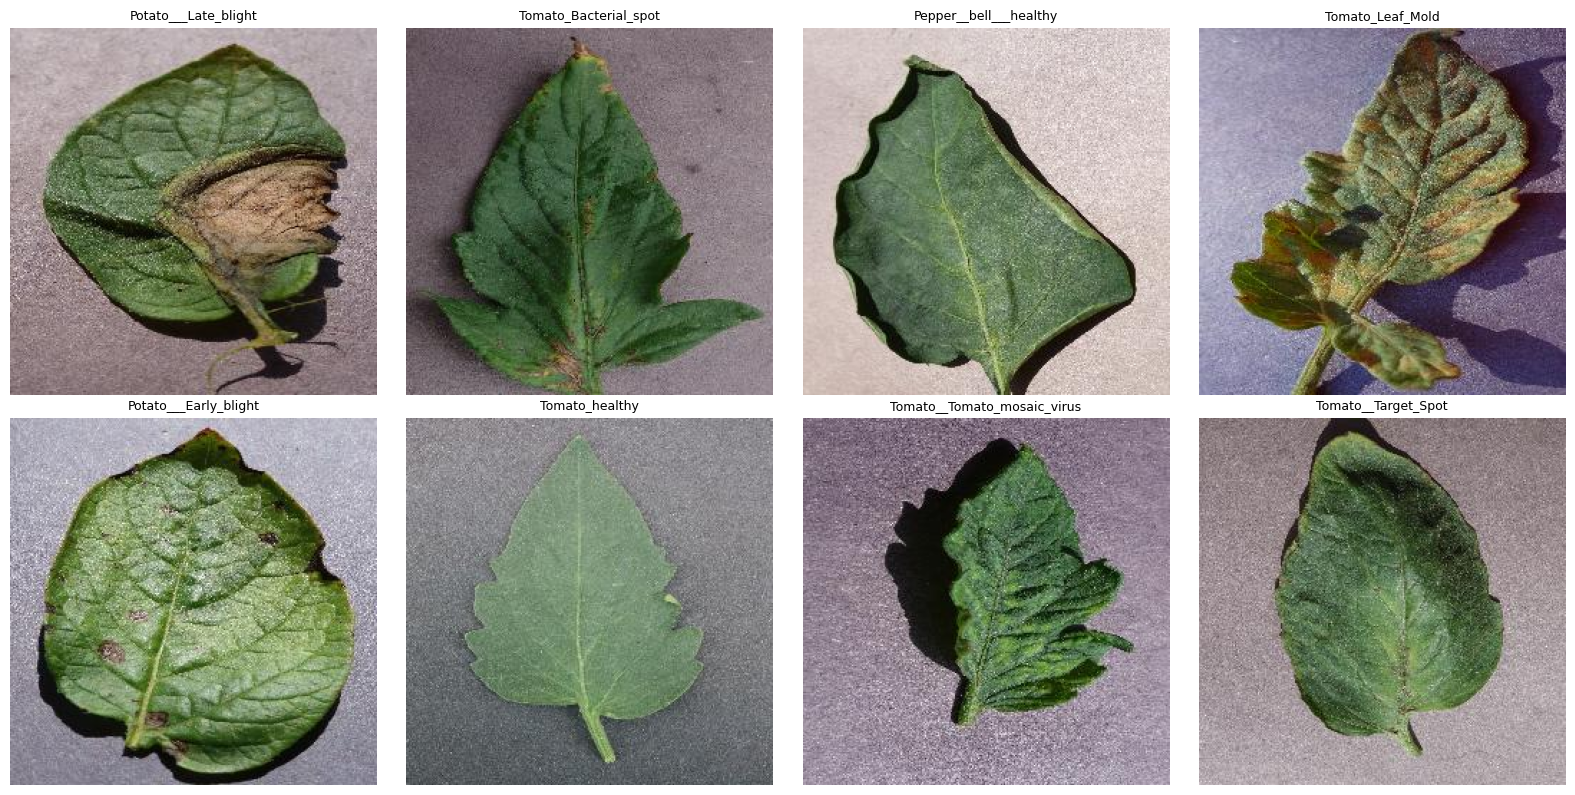

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = random.sample(classes, 8)

for ax, cls in zip(axes.flatten(), sample_classes):
    class_path = os.path.join(DATA_DIR, cls)
    sample_img_name = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, sample_img_name))
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2          # 80% train, 20% val
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)
DATA_DIR = "/kaggle/input/plant-village/PlantVillage"
NUM_CLASSES = len(os.listdir(DATA_DIR))
print("Using data dir:", DATA_DIR)
print("Number of classes:", NUM_CLASSES)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# Handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights = dict(enumerate(class_weights))

Found 16516 images belonging to 15 classes.
Using data dir: /kaggle/input/plant-village/PlantVillage
Number of classes: 15
Found 4122 images belonging to 15 classes.


In [10]:
# Load MobileNetV2 pretrained on ImageNet, without the top classifier
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Phase 1: Freeze base model for feature extraction
base_model.trainable = False

# Custom classification head with regularization (Task 4)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,625,871 (10.02 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_model_phase1.keras", monitor="val_accuracy", save_best_only=True)
]

In [12]:
history_1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 456s 836ms/step - accuracy: 0.6208 - loss: 1.6326 - val_accuracy: 0.8246 - val_loss: 1.1549 - learning_rate: 0.0010
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 322s 623ms/step - accuracy: 0.7490 - loss: 1.3387 - val_accuracy: 0.8498 - val_loss: 1.0941 - learning_rate: 0.0010
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 322s 623ms/step - accuracy: 0.7879 - loss: 1.2599 - val_accuracy: 0.8617 - val_loss: 1.0533 - learning_rate: 0.0010
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 324s 628ms/step - accuracy: 0.8090 - loss: 1.2093 - val_accuracy: 0.8768 - val_loss: 1.0234 - learning_rate: 0.0010
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 331s 641ms/step - accuracy: 0.8256 - loss: 1.1682 - val_accuracy: 0.8802 - val_loss: 1.0057 - learning_rate: 0.0010
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 329s 637ms/step - accuracy: 0.8385 - loss: 1.1454 - val_accuracy: 0.8804 - val_loss: 1.0063 - learning_rate: 0.0010
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 335s 647ms/step - accura

In [1]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks_finetune = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-8),
    ModelCheckpoint("best_model_finetuned.keras", monitor="val_accuracy", save_best_only=True)
]

history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

NameError: name 'base_model' is not defined

In [ ]:
loss, acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {acc*100:.2f}%")

def plot_history(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.legend(); plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend(); plt.title("Loss")
    plt.savefig("training_curves.png")
    plt.show()

plot_history(history_1, history_2)

In [ ]:

model.save("crop_disease_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open("crop_disease_model_fp16.tflite", "wb") as f:
    f.write(tflite_model)

print("Float16 TFLite model saved. Size (MB):",
      len(tflite_model) / (1024 * 1024))

def representative_dataset():
    for images, _ in train_generator:
        for i in range(min(len(images), 1)):
            yield [np.expand_dims(images[i], axis=0).astype(np.float32)]
        break

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.uint8
converter_int8.inference_output_type = tf.uint8
tflite_int8_model = converter_int8.convert()

with open("crop_disease_model_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print("INT8 TFLite model saved. Size (MB):",
      len(tflite_int8_model) / (1024 * 1024))

In [ ]:
interpreter = tf.lite.Interpreter(model_path="crop_disease_model_fp16.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def predict_leaf_image(img_path, class_names):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]["index"], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]["index"])[0]

    predicted_class = class_names[np.argmax(output)]
    confidence = np.max(output) * 100
    return predicted_class, confidence
